<a href="https://colab.research.google.com/github/sulucay01/DI725-assignment1/blob/dev/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis

## 1. Data Loading and Initial Inspection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

train = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/main/data/raw/train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/main/data/raw/test.csv")

In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (970, 11)
Test shape: (30, 11)


In [4]:
train.head()

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or email address during login,Mobile Number and Email Verification -> Verification requirement for mobile number or email address during login,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.","Agent: Thank you for calling BrownBox Customer Support. My name is Tom. How may I assist you today?\n\nCustomer: Hi Tom, I'm trying to log in to my account to purchase an Oven Toaster Grill (OTG),..."
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked to ship the item,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.",Agent: Thank you for calling BrownBox customer support. My name is Alex. How may I assist you today?\n\nCustomer: Hi Alex. I recently received an email from BrownBox requesting me to ship back the...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to click the 'Cancel' button,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, excel in de-escalation, and possess the ability to empathize with customers, providing them with effective solutions and support.","Agent: Thank you for calling BrownBox Customer Support. My name is Sarah. How may I assist you today?\n\nCustomer: Hi Sarah, I am calling because I am unable to click the 'Cancel' button for my Ju..."
3,Login and Account,Login Issues and Error Messages,Error message regarding exceeded attempts to enter the correct verification code,Login Issues and Error Messages -> Error message regarding exceeded attempts to enter the correct verification code,neutral,Appliances,Water Purifier,less,inexperienced,"may struggle with ambiguous queries, rely on clarification from customers or guidance from senior team members, find it difficult to de-escalate tense situations, and may rely on predefined steps ...","Customer: Hi, I am facing an issue while logging into my account. I am getting an error message saying that I have exceeded the number of attempts to enter the correct verification code.\n\nAgent:..."
4,Order,Order Delivery Issues,Delivery not attempted again,Order Delivery Issues -> Delivery not attempted again,negative,Electronics,Bp Monitor,medium,experienced,"confidently handles complex customer issues, excel in de-escalation, and possess the ability to empathize with customers, providing them with effective solutions and support.","Agent: Thank you for contacting BrownBox customer support. My name is Sarah. How can I assist you today?\n\nCustomer: Hi Sarah, I have an issue with my order. I received a BP monitor, but the deli..."


In [5]:
train.columns.tolist()

['issue_area',
 'issue_category',
 'issue_sub_category',
 'issue_category_sub_category',
 'customer_sentiment',
 'product_category',
 'product_sub_category',
 'issue_complexity',
 'agent_experience_level',
 'agent_experience_level_desc',
 'conversation']

The training dataset contains 970 rows and 11 columns, while the test dataset contains 30 rows and 11 columns. The data includes several categorical variables related to issue type, product, and agent experience, along with the conversation text and the target variable customer_sentiment.

## 2. Dataset Structure and Data Quality

In [6]:
#Inspect Data Types
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   issue_area                   970 non-null    object
 1   issue_category               970 non-null    object
 2   issue_sub_category           970 non-null    object
 3   issue_category_sub_category  970 non-null    object
 4   customer_sentiment           970 non-null    object
 5   product_category             970 non-null    object
 6   product_sub_category         970 non-null    object
 7   issue_complexity             970 non-null    object
 8   agent_experience_level       970 non-null    object
 9   agent_experience_level_desc  970 non-null    object
 10  conversation                 970 non-null    object
dtypes: object(11)
memory usage: 83.5+ KB


The dataset contains **970 observations and 11 columns**, and all features are stored as `object` data types. Most of the variables represent **categorical attributes** describing the issue type, product category, and agent experience level.

The `conversation` column contains **unstructured text data**, which will serve as the primary input for the sentiment classification model. The target variable `customer_sentiment` indicates the sentiment of the conversation and contains three possible classes.

In [7]:
#Check Missing Values
missing = train.isnull().sum().sort_values(ascending=False)
missing

,0
issue_area,0
issue_category,0
issue_sub_category,0
issue_category_sub_category,0
customer_sentiment,0
product_category,0
product_sub_category,0
issue_complexity,0
agent_experience_level,0
agent_experience_level_desc,0


The missing value analysis shows that **none of the features contain missing values**. All columns have 970 non-null observations.

This indicates that the dataset is **complete and clean**, and no missing value handling or imputation is required before further analysis or modeling.

In [8]:
#Check Duplicate Rows
train.duplicated().sum()

np.int64(0)

The dataset contains **no duplicate rows**, meaning each observation represents a unique customer interaction. Therefore, no duplicate removal is necessary at this stage.

In [9]:
#Inspect Unique Values of Categorical Features
categorical_cols = train.select_dtypes(include="object").columns
categorical_cols

Index(['issue_area', 'issue_category', 'issue_sub_category',
       'issue_category_sub_category', 'customer_sentiment', 'product_category',
       'product_sub_category', 'issue_complexity', 'agent_experience_level',
       'agent_experience_level_desc', 'conversation'],
      dtype='object')

In [10]:
for col in categorical_cols:
    print(col, train[col].nunique())

issue_area 6
issue_category 40
issue_sub_category 109
issue_category_sub_category 109
customer_sentiment 3
product_category 3
product_sub_category 50
issue_complexity 3
agent_experience_level 3
agent_experience_level_desc 3
conversation 968


The categorical features show varying levels of cardinality:

- `issue_area` contains **6 unique categories**
- `issue_category` contains **40 categories**
- `issue_sub_category` and `issue_category_sub_category` contain **109 categories**
- `product_category` contains **3 categories**
- `product_sub_category` contains **50 categories**
- `issue_complexity` contains **3 levels**
- `agent_experience_level` and `agent_experience_level_desc` contain **3 levels**
- `customer_sentiment` contains **3 classes**
- `conversation` contains **968 unique text entries**

The high number of unique values in the `conversation` column confirms that most conversations are distinct, which is expected for customer service interactions.

Features such as `issue_sub_category` and `product_sub_category` have relatively high cardinality, which may require careful handling during feature encoding if they are used as additional inputs to the model.

## 3. Target Variable Distribution

Sentiment counts:
customer_sentiment
neutral     542
negative    411
positive     17
Name: count, dtype: int64

Sentiment percentages:
customer_sentiment
neutral     55.88
negative    42.37
positive     1.75
Name: proportion, dtype: float64


/tmp/ipykernel_1067/1591159626.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


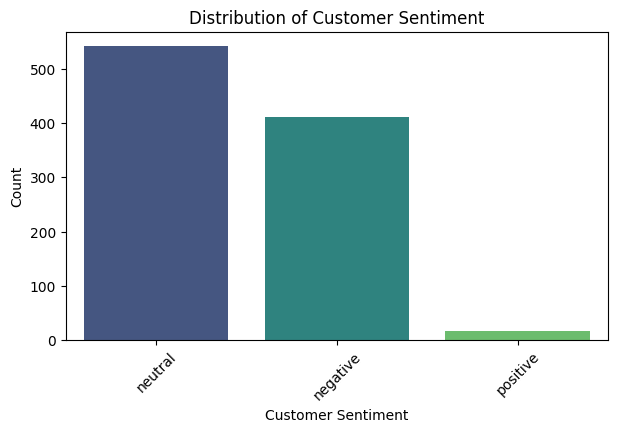

In [11]:
# Distribution of target variable
sentiment_counts = train["customer_sentiment"].value_counts()
sentiment_ratios = train["customer_sentiment"].value_counts(normalize=True) * 100

print("Sentiment counts:")
print(sentiment_counts)
print("\nSentiment percentages:")
print(sentiment_ratios.round(2))

plt.figure(figsize=(7,4))

palette = sns.color_palette("viridis", train["customer_sentiment"].nunique())

sns.countplot(
    data=train,
    x="customer_sentiment",
    order=train["customer_sentiment"].value_counts().index,
    palette=palette
)

plt.title("Distribution of Customer Sentiment")
plt.xlabel("Customer Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The distribution of the target variable shows that the dataset is highly imbalanced. The majority of the observations belong to the neutral class, followed by the negative class. The positive class appears only in a very small portion of the dataset.

## 4. Conversation Length Analysis

Character Length Summary:


,char_length
count,970.000000
mean,2129.284536
std,564.751035
min,46.000000
25%,1760.250000
50%,2058.500000
75%,2430.000000
max,5708.000000



Word Count Summary:


,word_count
count,970.000000
mean,370.860825
std,98.267606
min,8.000000
25%,306.000000
50%,357.000000
75%,424.000000
max,992.000000



Word Count Percentiles:
50th percentile (median): 357
75th percentile: 424
90th percentile: 494
95th percentile: 554


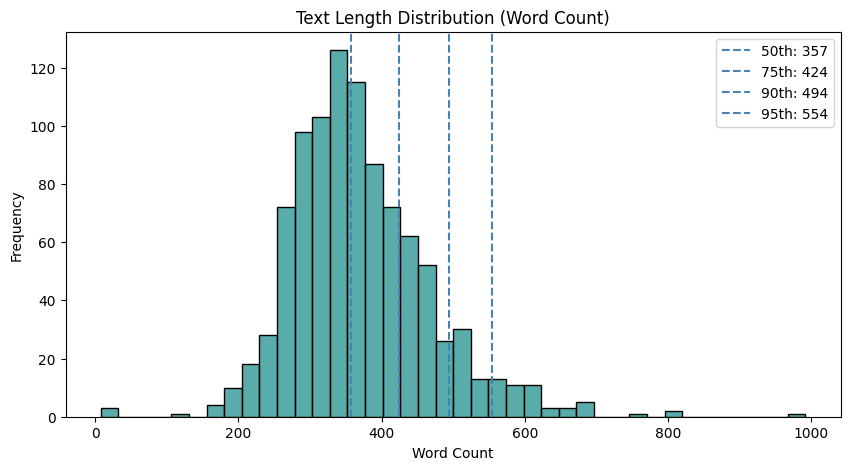

/tmp/ipykernel_1067/4154719795.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


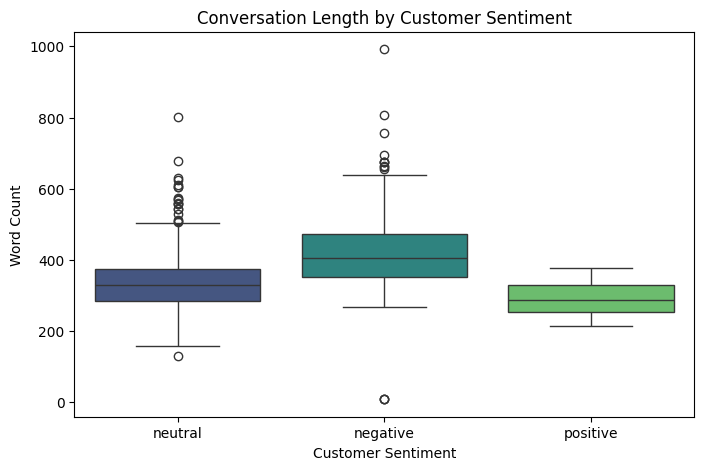

Word Count Summary by Sentiment:


,count,mean,std,min,25%,50%,75%,max
customer_sentiment,,,,,,,,
negative,411.0,417.67,101.35,8.0,351.5,406.0,471.5,992.0
neutral,542.0,337.78,80.60,129.0,285.0,329.0,373.0,802.0
positive,17.0,294.00,48.18,213.0,253.0,286.0,329.0,378.0


In [12]:
# Create text length features
train["char_length"] = train["conversation"].apply(lambda x: len(str(x)))
train["word_count"] = train["conversation"].apply(lambda x: len(str(x).split()))

# Display summary statistics
print("Character Length Summary:")
display(train["char_length"].describe())

print("\nWord Count Summary:")
display(train["word_count"].describe())

# Calculate percentiles for word count
p50 = np.percentile(train["word_count"], 50)
p75 = np.percentile(train["word_count"], 75)
p90 = np.percentile(train["word_count"], 90)
p95 = np.percentile(train["word_count"], 95)

print("\nWord Count Percentiles:")
print(f"50th percentile (median): {p50:.0f}")
print(f"75th percentile: {p75:.0f}")
print(f"90th percentile: {p90:.0f}")
print(f"95th percentile: {p95:.0f}")

# --------------------------------------------
# Histogram of word counts with percentile lines
# --------------------------------------------
plt.figure(figsize=(10, 5))

sns.histplot(
    train["word_count"],
    bins=40,
    color=sns.color_palette("viridis", 1)[0]
)

plt.axvline(p50, linestyle="--", color="steelblue", label=f"50th: {int(p50)}")
plt.axvline(p75, linestyle="--", color="steelblue", label=f"75th: {int(p75)}")
plt.axvline(p90, linestyle="--", color="steelblue", label=f"90th: {int(p90)}")
plt.axvline(p95, linestyle="--", color="steelblue", label=f"95th: {int(p95)}")

plt.title("Text Length Distribution (Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# --------------------------------------------
# Boxplot of word count by sentiment class
# --------------------------------------------
plt.figure(figsize=(8, 5))

palette = sns.color_palette("viridis", train["customer_sentiment"].nunique())

sns.boxplot(
    data=train,
    x="customer_sentiment",
    y="word_count",
    order=train["customer_sentiment"].value_counts().index,
    palette=palette
)

plt.title("Conversation Length by Customer Sentiment")
plt.xlabel("Customer Sentiment")
plt.ylabel("Word Count")
plt.show()

# --------------------------------------------
# Group-wise summary statistics by sentiment
# --------------------------------------------
length_summary_by_sentiment = train.groupby("customer_sentiment")["word_count"].describe().round(2)
print("Word Count Summary by Sentiment:")
display(length_summary_by_sentiment)

The average conversation length is approximately 371 words, with a median of 357 words, indicating that most customer interactions are relatively long and detailed. The distribution shows moderate variability, with a standard deviation of about 98 words.
The percentile analysis further illustrates the distribution of conversation lengths. Specifically, 50% of the conversations contain fewer than 357 words, while 75% contain fewer than 424 words. The 90th percentile is 494 words, and 95% of the conversations are shorter than 554 words. This indicates that although most conversations fall within a moderate range, a small number of interactions are significantly longer, reaching up to 992 words.
The histogram confirms a right-skewed distribution, where the majority of conversations cluster between approximately 250 and 450 words, with fewer extremely long conversations forming the tail of the distribution.

The boxplot comparing conversation length across sentiment classes reveals that negative conversations tend to be longer on average, with a mean of approximately 418 words, compared to 338 words for neutral conversations and 294 words for positive conversations. This pattern may indicate that customers expressing negative sentiment often provide more detailed explanations of their issues.

## 5. Relationship Between Low-Cardinality Features and Sentiment

In [13]:
#Crosstab Analysis
features_to_analyze = [
    "issue_complexity",
    "agent_experience_level",
    "product_category",
    "issue_area"
]

for col in features_to_analyze:
    print(f"\nSentiment distribution by {col}:")

    table = pd.crosstab(
        train[col],
        train["customer_sentiment"],
        normalize="index"
    ).round(3)

    display(table)


Sentiment distribution by issue_complexity:


customer_sentiment,negative,neutral,positive
issue_complexity,,,
high,0.476,0.488,0.037
less,0.417,0.568,0.015
medium,0.421,0.562,0.017



Sentiment distribution by agent_experience_level:


customer_sentiment,negative,neutral,positive
agent_experience_level,,,
experienced,0.434,0.555,0.012
inexperienced,0.333,0.660,0.007
junior,0.443,0.533,0.024



Sentiment distribution by product_category:


customer_sentiment,negative,neutral,positive
product_category,,,
Appliances,0.419,0.562,0.020
Electronics,0.416,0.580,0.003
Men/Women/Kids,0.444,0.525,0.031



Sentiment distribution by issue_area:


customer_sentiment,negative,neutral,positive
issue_area,,,
Cancellations and returns,0.491,0.509,0.000
Login and Account,0.188,0.812,0.000
Order,0.605,0.329,0.066
Shipping,0.529,0.471,0.000
Shopping,0.319,0.681,0.000
Warranty,0.175,0.825,0.000


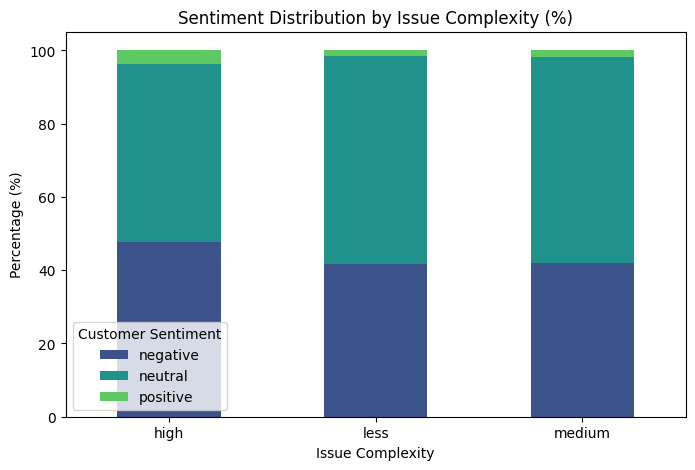

In [14]:
#Visualization

#Issue Complexity
complexity_sentiment = pd.crosstab(
    train["issue_complexity"],
    train["customer_sentiment"],
    normalize="index"
) * 100

complexity_sentiment = complexity_sentiment.round(1)

palette = sns.color_palette("viridis", complexity_sentiment.shape[1])

complexity_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=palette
)

plt.title("Sentiment Distribution by Issue Complexity (%)")
plt.xlabel("Issue Complexity")
plt.ylabel("Percentage (%)")
plt.legend(title="Customer Sentiment")
plt.xticks(rotation=0)

plt.show()

The sentiment distribution shows that conversations associated with high complexity issues have a slightly higher proportion of negative sentiment (47.6%) compared to medium (42.1%) and less complex issues (41.7%). This suggests that more complex customer problems may lead to greater dissatisfaction, which is reflected in the sentiment expressed during the interaction.

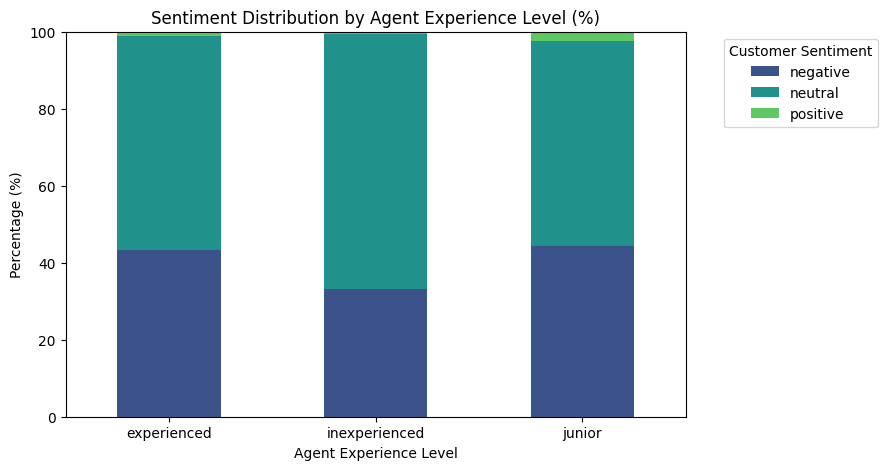

In [15]:
#Agent Experience Level

agent_sentiment = pd.crosstab(
    train["agent_experience_level"],
    train["customer_sentiment"],
    normalize="index"
) * 100

agent_sentiment = agent_sentiment[["negative", "neutral", "positive"]].round(1)

agent_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=palette
)

plt.title("Sentiment Distribution by Agent Experience Level (%)")
plt.xlabel("Agent Experience Level")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Customer Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.ylim(0, 100)
plt.show()

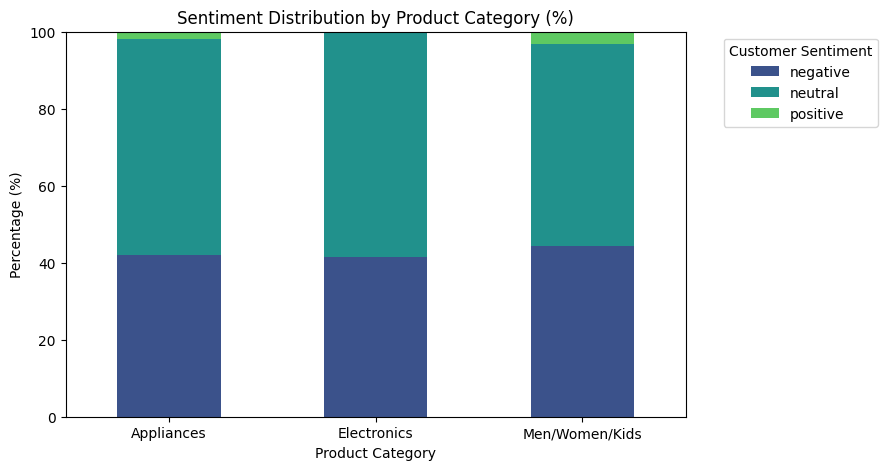

In [16]:
#Product Category
product_sentiment = pd.crosstab(
    train["product_category"],
    train["customer_sentiment"],
    normalize="index"
) * 100

product_sentiment = product_sentiment[["negative", "neutral", "positive"]].round(1)

product_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=palette
)

plt.title("Sentiment Distribution by Product Category (%)")
plt.xlabel("Product Category")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Customer Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.ylim(0, 100)
plt.show()

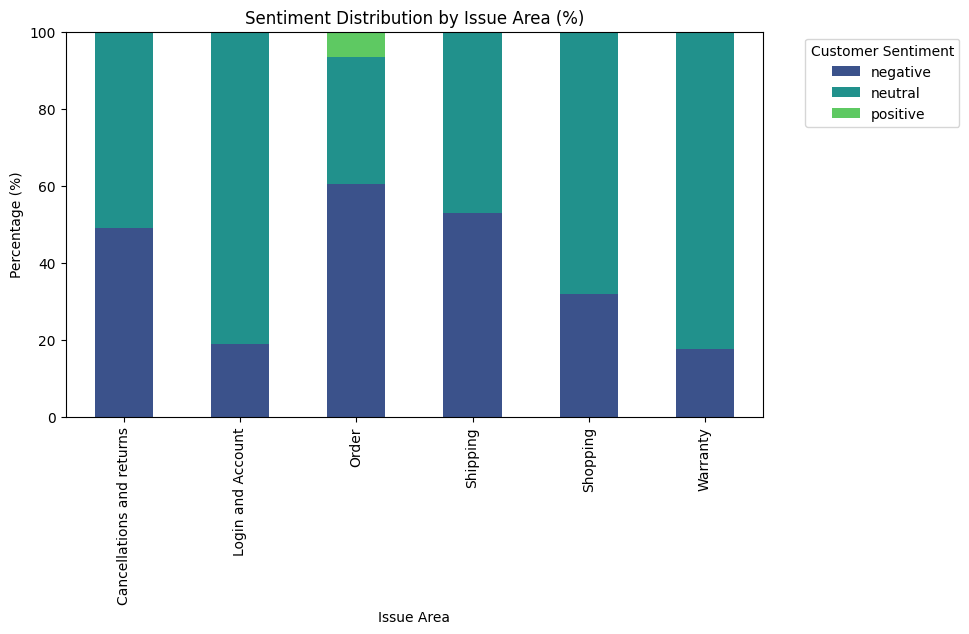

In [17]:
#Issue Area

issue_area_sentiment = pd.crosstab(
    train["issue_area"],
    train["customer_sentiment"],
    normalize="index"
) * 100

issue_area_sentiment = issue_area_sentiment[["negative","neutral","positive"]].round(1)

issue_area_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    color=palette
)

plt.title("Sentiment Distribution by Issue Area (%)")
plt.xlabel("Issue Area")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=90)
plt.legend(title="Customer Sentiment", bbox_to_anchor=(1.05,1))
plt.ylim(0,100)

plt.show()

## 6. Relationship Between High-Cardinality Features and Sentiment


Top categories for issue_category


/tmp/ipykernel_1067/2531188681.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


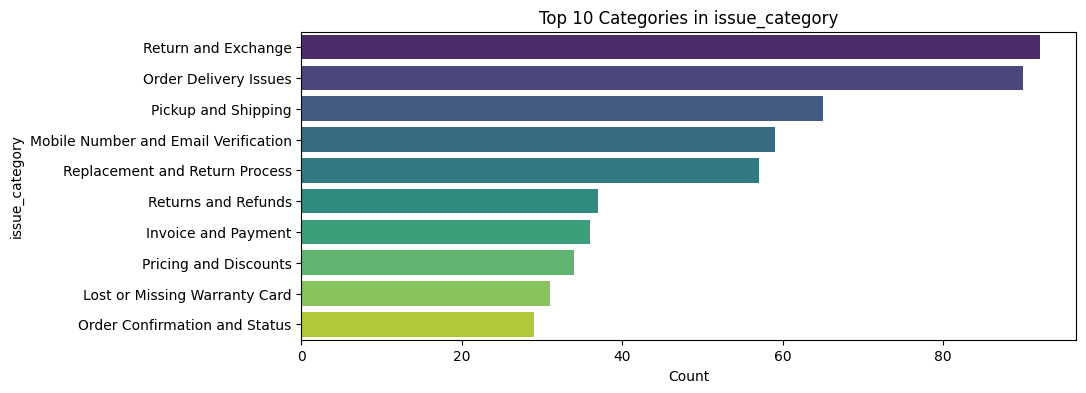

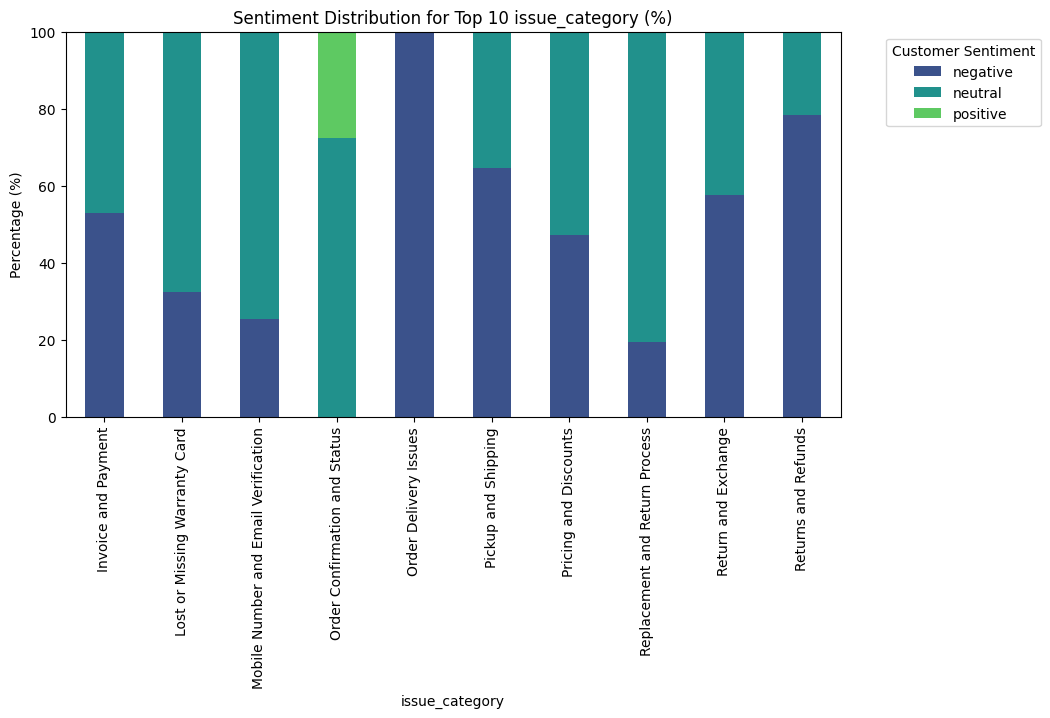


Top categories for issue_sub_category


/tmp/ipykernel_1067/2531188681.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


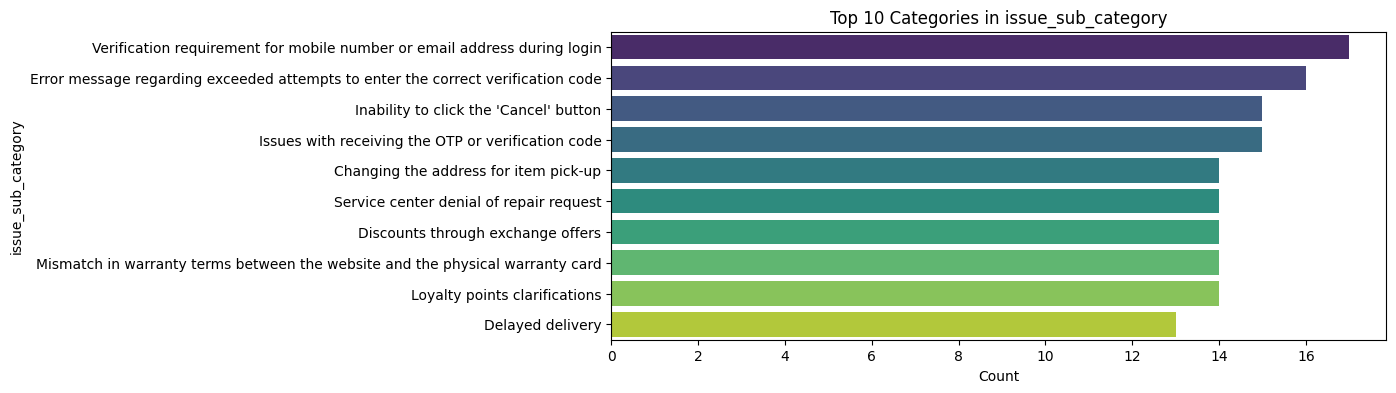

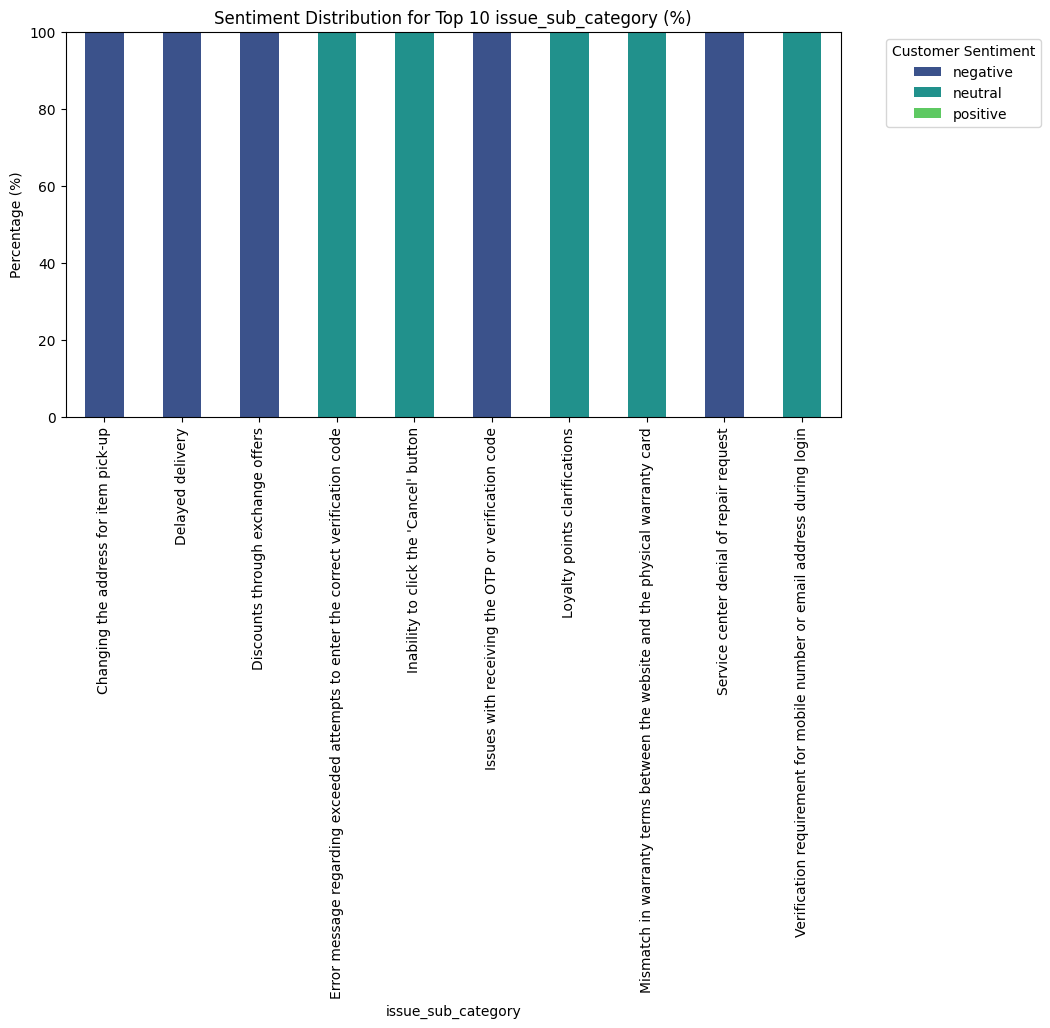


Top categories for issue_category_sub_category


/tmp/ipykernel_1067/2531188681.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


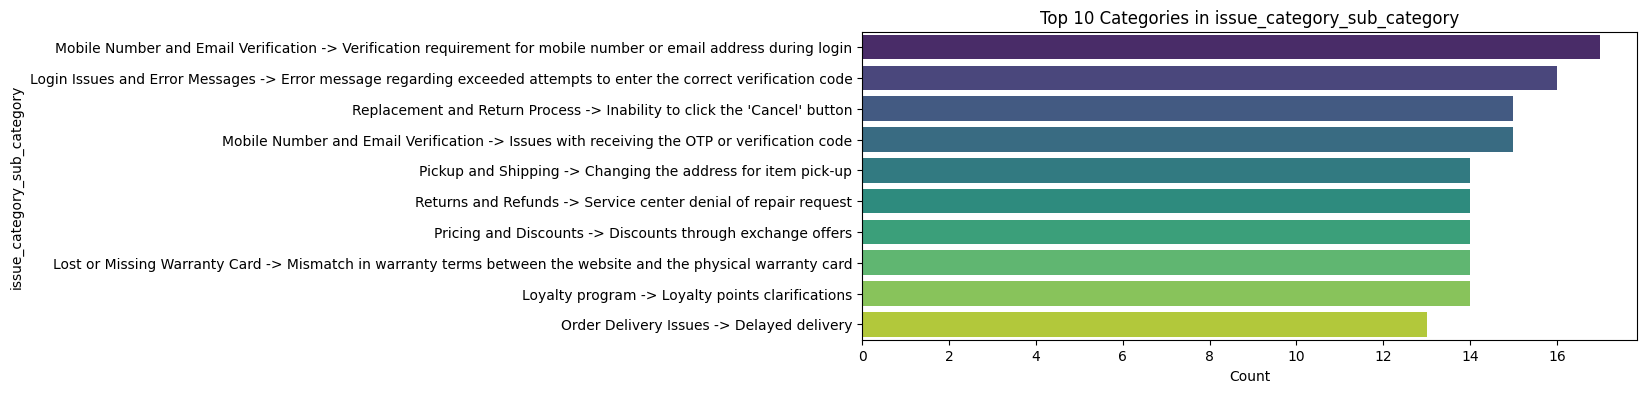

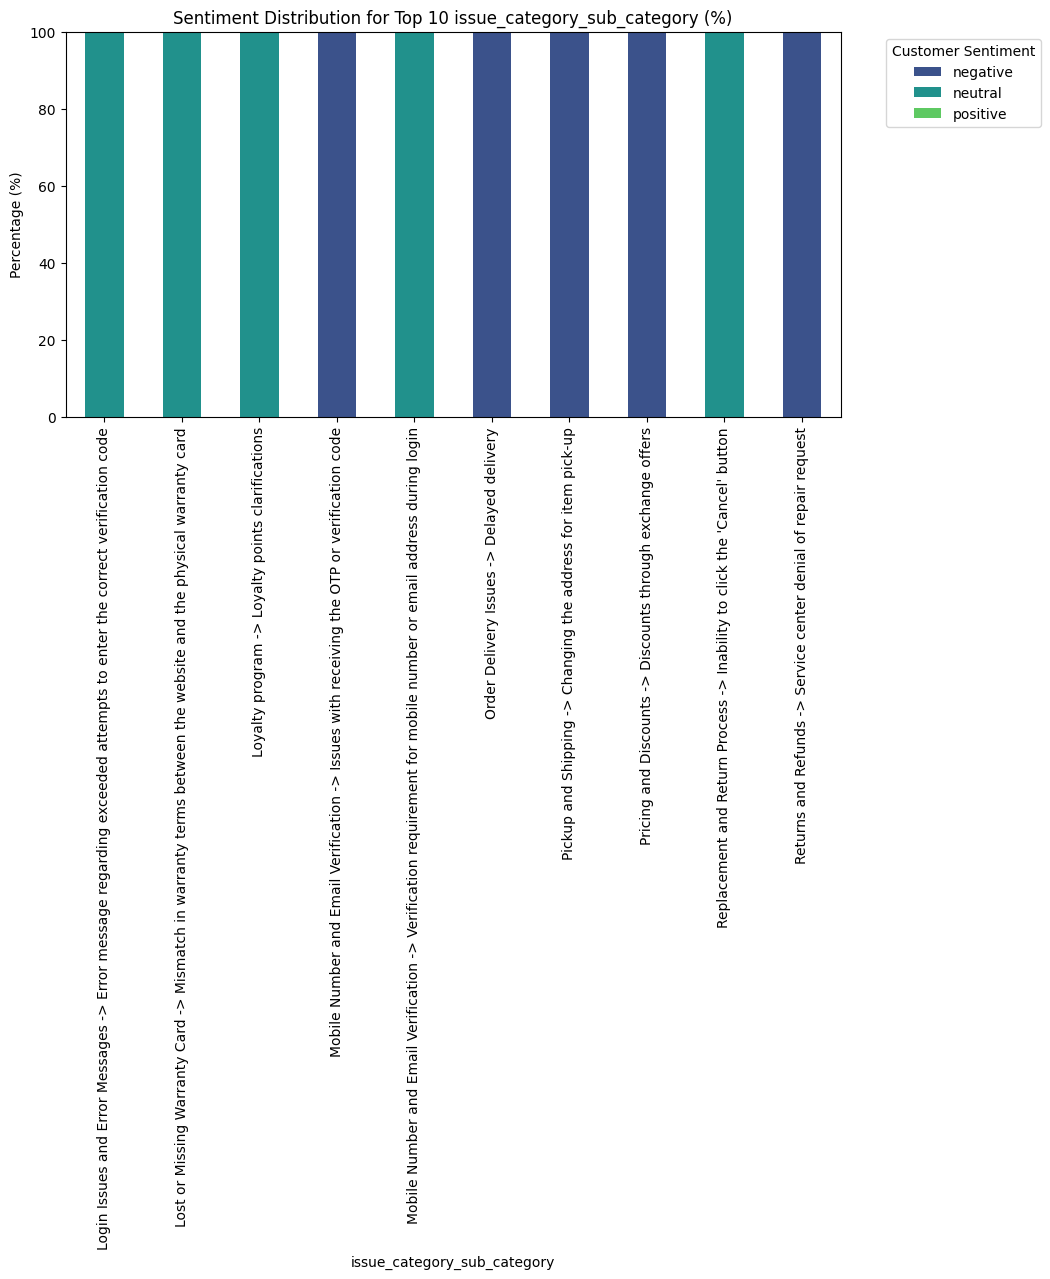


Top categories for product_sub_category


/tmp/ipykernel_1067/2531188681.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


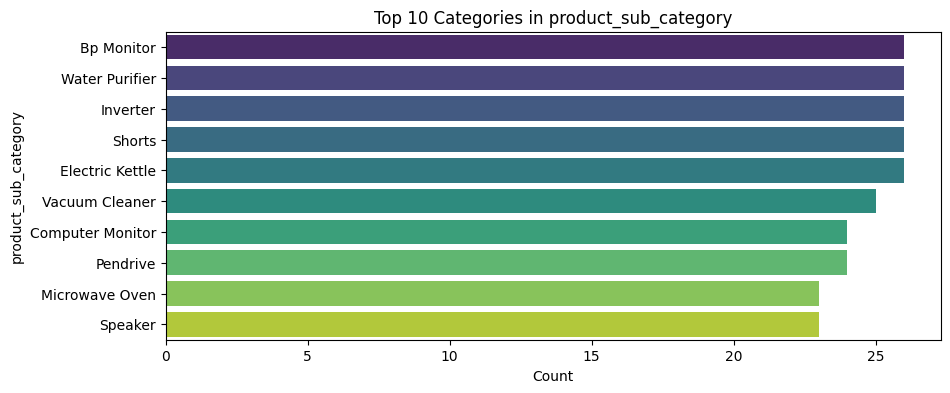

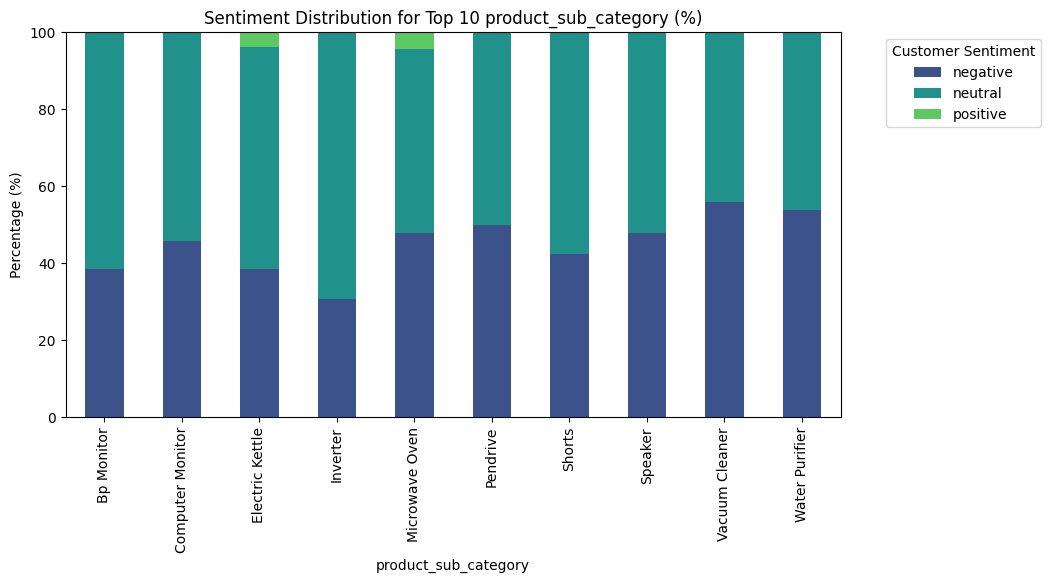

In [18]:
high_cardinality_cols = [
    "issue_category",
    "issue_sub_category",
    "issue_category_sub_category",
    "product_sub_category"
]

palette_counts = sns.color_palette("viridis", 10)
palette_sentiment = sns.color_palette("viridis", 3)

for col in high_cardinality_cols:

    print(f"\nTop categories for {col}")

    # Top 10 categories
    top10 = train[col].value_counts().head(10)

    # ---- Plot 1: Top 10 frequency ----
    plt.figure(figsize=(10,4))

    sns.barplot(
        x=top10.values,
        y=top10.index,
        palette=palette_counts
    )

    plt.title(f"Top 10 Categories in {col}")
    plt.xlabel("Count")
    plt.ylabel(col)

    plt.show()

    # ---- Plot 2: Sentiment distribution for top 10 ----
    filtered = train[train[col].isin(top10.index)]

    sentiment_table = pd.crosstab(
        filtered[col],
        filtered["customer_sentiment"],
        normalize="index"
    ) * 100


    sentiment_table = sentiment_table.reindex(
        columns=["negative", "neutral", "positive"],
        fill_value=0
    ).round(1)


    sentiment_table.plot(
        kind="bar",
        stacked=True,
        figsize=(10,5),
        color=palette_sentiment
    )

    plt.title(f"Sentiment Distribution for Top 10 {col} (%)")
    plt.xlabel(col)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=90)
    plt.legend(title="Customer Sentiment", bbox_to_anchor=(1.05,1))
    plt.ylim(0,100)

    plt.show()

## 7. Feature Relevance Analysis

Chi-Square Test Results:


,feature,chi2_statistic,degrees_of_freedom,p_value,significant_at_0_05
0,issue_sub_category,1940.000000,216,1.909643e-274,Yes
1,issue_category,1059.213726,78,6.586368e-172,Yes
2,issue_area,168.893250,10,4.701405e-31,Yes
3,agent_experience_level,9.259813,4,5.492353e-02,No
4,product_category,6.906161,4,1.409311e-01,No
5,issue_complexity,3.300219,4,5.088975e-01,No
6,product_sub_category,88.245879,98,7.496001e-01,No


Mutual Information Scores:


,feature,mutual_information
0,issue_sub_category,0.759935
1,issue_category,0.354769
2,issue_area,0.089940
3,product_sub_category,0.044173
4,agent_experience_level,0.004911
5,product_category,0.004177
6,issue_complexity,0.001503


Combined Feature Relevance Summary:


,feature,chi2_statistic,degrees_of_freedom,p_value,significant_at_0_05,mutual_information
0,issue_sub_category,1940.000000,216,1.909643e-274,Yes,0.759935
1,issue_category,1059.213726,78,6.586368e-172,Yes,0.354769
2,issue_area,168.893250,10,4.701405e-31,Yes,0.089940
3,product_sub_category,88.245879,98,7.496001e-01,No,0.044173
4,agent_experience_level,9.259813,4,5.492353e-02,No,0.004911
5,product_category,6.906161,4,1.409311e-01,No,0.004177
6,issue_complexity,3.300219,4,5.088975e-01,No,0.001503


/tmp/ipykernel_1067/491469358.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


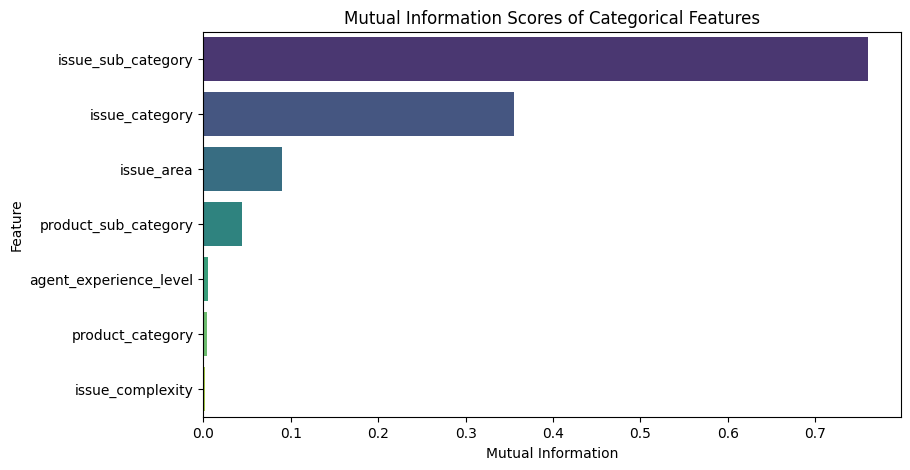

/tmp/ipykernel_1067/491469358.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


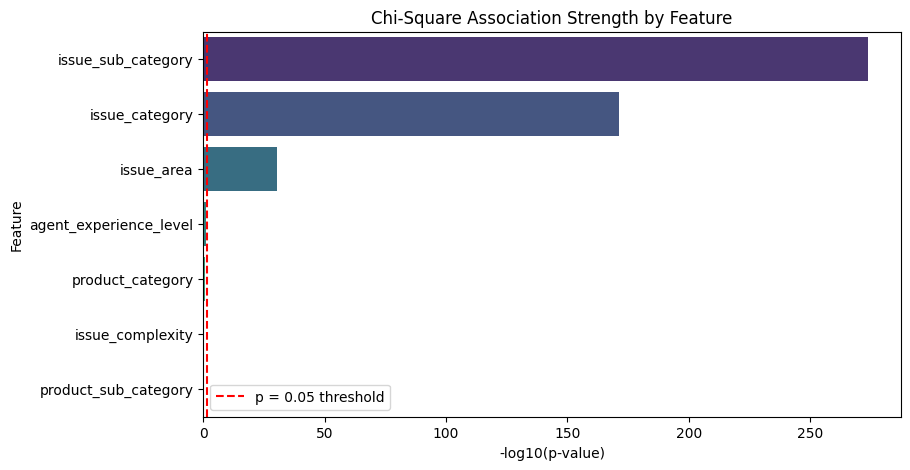

In [19]:
# ============================================
# 7. Feature Relevance Analysis
# ============================================

from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

features_for_relevance = [
    "issue_complexity",
    "agent_experience_level",
    "product_category",
    "issue_area",
    "issue_category",
    "issue_sub_category",
    "product_sub_category"
]

# --------------------------------------------
# 7.1 Chi-Square Test for Association
# --------------------------------------------
chi2_results = []

for col in features_for_relevance:
    contingency_table = pd.crosstab(train[col], train["customer_sentiment"])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    chi2_results.append({
        "feature": col,
        "chi2_statistic": chi2,
        "degrees_of_freedom": dof,
        "p_value": p,
        "significant_at_0_05": "Yes" if p < 0.05 else "No"
    })

chi2_results_df = pd.DataFrame(chi2_results).sort_values("p_value").reset_index(drop=True)

print("Chi-Square Test Results:")
display(chi2_results_df)

# --------------------------------------------
# 7.2 Mutual Information for Predictive Relevance
# --------------------------------------------
X_mi = train[features_for_relevance].copy()
y_mi = train["customer_sentiment"].copy()

for col in X_mi.columns:
    le = LabelEncoder()
    X_mi[col] = le.fit_transform(X_mi[col])

target_le = LabelEncoder()
y_mi = target_le.fit_transform(y_mi)

mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    discrete_features=True,
    random_state=42
)

mi_results_df = pd.DataFrame({
    "feature": features_for_relevance,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False).reset_index(drop=True)

print("Mutual Information Scores:")
display(mi_results_df)

# --------------------------------------------
# 7.3 Merge Results into One Summary Table
# --------------------------------------------
feature_relevance_df = chi2_results_df.merge(
    mi_results_df,
    on="feature",
    how="left"
).sort_values(["mutual_information", "p_value"], ascending=[False, True]).reset_index(drop=True)

print("Combined Feature Relevance Summary:")
display(feature_relevance_df)

# --------------------------------------------
# 7.4 Visualization: Mutual Information
# --------------------------------------------
plt.figure(figsize=(9, 5))

sns.barplot(
    data=mi_results_df,
    x="mutual_information",
    y="feature",
    palette=sns.color_palette("viridis", len(mi_results_df))
)

plt.title("Mutual Information Scores of Categorical Features")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.show()

# --------------------------------------------
# 7.5 Visualization: -log10(p-value) from Chi-Square
# --------------------------------------------
chi2_plot_df = chi2_results_df.copy()
chi2_plot_df["minus_log10_p_value"] = -np.log10(chi2_plot_df["p_value"].replace(0, 1e-300))

plt.figure(figsize=(9, 5))

sns.barplot(
    data=chi2_plot_df.sort_values("minus_log10_p_value", ascending=False),
    x="minus_log10_p_value",
    y="feature",
    palette=sns.color_palette("viridis", len(chi2_plot_df))
)

plt.axvline(-np.log10(0.05), linestyle="--", color="red", label="p = 0.05 threshold")

plt.title("Chi-Square Association Strength by Feature")
plt.xlabel("-log10(p-value)")
plt.ylabel("Feature")
plt.legend()
plt.show()

## 8. Correlation Between Categorical Features

In [20]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

# Variables to include
corr_features = [
    "issue_complexity",
    "agent_experience_level",
    "product_category",
    "issue_area",
    "customer_sentiment"
]

# Create correlation matrix
cramers_matrix = pd.DataFrame(index=corr_features, columns=corr_features)

for col1 in corr_features:
    for col2 in corr_features:
        cramers_matrix.loc[col1, col2] = cramers_v(train[col1], train[col2])

cramers_matrix = cramers_matrix.astype(float)

display(cramers_matrix)

,issue_complexity,agent_experience_level,product_category,issue_area,customer_sentiment
issue_complexity,1.000000,0.026147,0.006056,0.084038,0.041245
agent_experience_level,0.026147,1.000000,0.034505,0.073921,0.069088
product_category,0.006056,0.034505,1.000000,0.152096,0.059665
issue_area,0.084038,0.073921,0.152096,1.000000,0.295057
customer_sentiment,0.041245,0.069088,0.059665,0.295057,1.000000


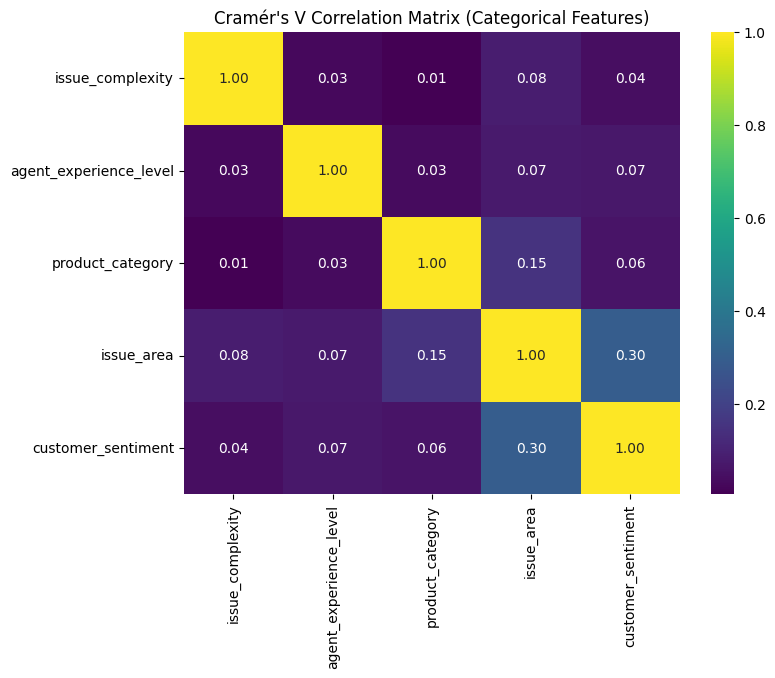

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Cramér's V Correlation Matrix (Categorical Features)")
plt.show()